# 일단 데이터 한번 가져와보기

`yfinance` 라이브러리를 이용하여 가져와보겠습니다.

### `yfinance`가 제공하는 기능
- Ticker
- Tickers (?)
- download
- search
- WebSocket
- Screener

### 제공하는 데이터
- 단일종목
- 여러종목
- 검색
- 실시간 스트리밍

> 공식 인증이나 Yahoo와 제휴된 도구가 아니라 조심히 써야함.

In [1]:
import yfinance as yf

df = yf.download("NVDA", start="2020-01-01", end="2026-01-01")

print(df.head())
print(df.info())


[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2020-01-02  5.970754  5.970754  5.891364  5.941885  237536000
2020-01-03  5.875188  5.918990  5.826160  5.851047  205384000
2020-01-06  5.899825  5.905051  5.755726  5.781858  262636000
2020-01-07  5.971253  6.017046  5.883151  5.928197  314856000
2020-01-08  5.982452  6.023765  5.926953  5.967022  277108000
<class 'pandas.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   1508 non-null   float64
 1   (High, NVDA)    1508 non-null   float64
 2   (Low, NVDA)     1508 non-null   float64
 3   (Open, NVDA)    1508 non-null   float64
 4   (Volume, NVDA)  1508 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.7 KB
None


# 티커 받고싶어서 `finance-datareader` 라이브러리 받음

In [2]:
import FinanceDataReader as fdr

nasdaq = fdr.StockListing("NASDAQ")
# print(nasdaq.head())

semiconductor_mask = nasdaq["Industry"] == "반도체"

# print(nasdaq[])

100%|██████████| 3898/3898 [00:05<00:00, 743.54it/s]


In [3]:
print(nasdaq[semiconductor_mask])

     Symbol                              Name IndustryCode Industry
0      NVDA                       NVIDIA Corp     57101010      반도체
5      AVGO                      Broadcom Inc     57101010      반도체
9        MU             Micron Technology Inc     57101010      반도체
11      AMD        Advanced Micro Devices Inc     57101010      반도체
13     INTC                        Intel Corp     57101010      반도체
...     ...                               ...          ...      ...
3273   PRSO                        Peraso Inc     57101010      반도체
3313   EBON  Ebang International Holdings Inc     57101010      반도체
3367   SELX         Semilux International Ltd     57101010      반도체
3516   SMTK                      SmartKem Inc     57101010      반도체
3872   DAIC                    CID HoldCo Inc     57101010      반도체

[76 rows x 4 columns]


In [4]:
import pandas as pd

print((nasdaq[semiconductor_mask]["Symbol"] == "MU").sum())

print(nasdaq[nasdaq["Symbol"].eq("MU")])

1
  Symbol                   Name IndustryCode Industry
9     MU  Micron Technology Inc     57101010      반도체


In [5]:
# print(nasdaq)

# print(etf_df.info())

nvda_df = fdr.DataReader(nasdaq[semiconductor_mask]["Symbol"][0])


In [6]:
nvda_df

,Open,High,Low,Close,Volume,Adj Close
1999-01-22,0.043750,0.048828,0.038802,0.041016,2714688000,0.037603
1999-01-25,0.044271,0.045833,0.041016,0.045313,510480000,0.041542
1999-01-26,0.045833,0.046745,0.041146,0.041797,343200000,0.038319
1999-01-27,0.041927,0.042969,0.039583,0.041667,244368000,0.038200
1999-01-28,0.041667,0.041927,0.041276,0.041536,227520000,0.038080
...,...,...,...,...,...,...
2026-05-22,220.899994,221.009995,214.800003,215.330002,169275700,215.330002
2026-05-26,216.539993,218.179993,212.000000,214.860001,187202600,214.860001
2026-05-27,214.119995,214.149994,208.779999,212.600006,167601200,212.600006
2026-05-28,211.279999,215.520004,211.220001,214.250000,143996000,214.250000


In [7]:
# nvda_df["change"] = pd.concat([nvda_df["Close"], pd.Series([0])], ignore_index=True) - pd.concat([pd.Series([0]) ,nvda_df["Close"]], ignore_index=True) 

# nvda_df["Close"]
nvda_df["change"] = pd.concat([pd.Series([0]) ,nvda_df["Close"]], ignore_index=True) - pd.concat([nvda_df["Close"], pd.Series([0])], ignore_index=True)[0:6879]

In [8]:
nvda_df

,Open,High,Low,Close,Volume,Adj Close,change
1999-01-22,0.043750,0.048828,0.038802,0.041016,2714688000,0.037603,NaN
1999-01-25,0.044271,0.045833,0.041016,0.045313,510480000,0.041542,NaN
1999-01-26,0.045833,0.046745,0.041146,0.041797,343200000,0.038319,NaN
1999-01-27,0.041927,0.042969,0.039583,0.041667,244368000,0.038200,NaN
1999-01-28,0.041667,0.041927,0.041276,0.041536,227520000,0.038080,NaN
...,...,...,...,...,...,...,...
2026-05-22,220.899994,221.009995,214.800003,215.330002,169275700,215.330002,NaN
2026-05-26,216.539993,218.179993,212.000000,214.860001,187202600,214.860001,NaN
2026-05-27,214.119995,214.149994,208.779999,212.600006,167601200,212.600006,NaN
2026-05-28,211.279999,215.520004,211.220001,214.250000,143996000,214.250000,NaN


In [9]:
nvda_df["change"] = nvda_df["Close"].diff().fillna(0)

In [11]:
nvda_df

,Open,High,Low,Close,Volume,Adj Close,change
1999-01-22,0.043750,0.048828,0.038802,0.041016,2714688000,0.037603,0.000000
1999-01-25,0.044271,0.045833,0.041016,0.045313,510480000,0.041542,0.004297
1999-01-26,0.045833,0.046745,0.041146,0.041797,343200000,0.038319,-0.003516
1999-01-27,0.041927,0.042969,0.039583,0.041667,244368000,0.038200,-0.000130
1999-01-28,0.041667,0.041927,0.041276,0.041536,227520000,0.038080,-0.000131
...,...,...,...,...,...,...,...
2026-05-22,220.899994,221.009995,214.800003,215.330002,169275700,215.330002,-4.179993
2026-05-26,216.539993,218.179993,212.000000,214.860001,187202600,214.860001,-0.470001
2026-05-27,214.119995,214.149994,208.779999,212.600006,167601200,212.600006,-2.259995
2026-05-28,211.279999,215.520004,211.220001,214.250000,143996000,214.250000,1.649994


In [13]:
print(nvda_df["change"].describe())
# std가 1이고, mean이 0.03으로 변화율에 편차가 꽤 있는 편이라고 보면 되나
# 시간에 따라 변동폭이 달라질 수 있으니 이것도 한번 보자

count    6880.000000
mean        0.030683
std         1.217251
min       -24.199997
25%        -0.009250
50%         0.000500
75%         0.013250
max        18.029999
Name: change, dtype: float64


In [16]:
print(type(nvda_df.index))

<class 'pandas.DatetimeIndex'>


In [19]:
print(nvda_df.groupby(nvda_df.index.year).mean())

            Open        High         Low       Close        Volume  \
1999    0.048770    0.050183    0.047089    0.048681  2.573288e+08   
2000    0.219527    0.230567    0.209013    0.219471  4.416727e+08   
2001    0.327281    0.340019    0.317014    0.329539  1.112955e+09   
2002    0.242259    0.248877    0.233610    0.240369  1.267462e+09   
2003    0.147561    0.151066    0.144124    0.147509  9.720881e+08   
2004    0.162118    0.165220    0.158839    0.161648  6.825325e+08   
2005    0.237810    0.241491    0.233829    0.237846  6.171300e+08   
2006    0.451448    0.460628    0.443007    0.452399  6.137791e+08   
2007    0.694051    0.706292    0.680151    0.693114  6.058254e+08   
2008    0.400108    0.410656    0.388037    0.398640  8.090886e+08   
2009    0.295628    0.302869    0.289149    0.296272  7.679284e+08   
2010    0.339409    0.345066    0.332963    0.339079  7.413180e+08   
2011    0.422813    0.431688    0.412804    0.422188  9.157406e+08   
2012    0.338155    

In [25]:
nvda_df["volume_billion"] = (nvda_df["Volume"]/1_000_000).round(2)

nvda_df = nvda_df.rename(columns={"volume_billion": "volume_million"})

nvda_df

,Open,High,Low,Close,Volume,Adj Close,change,volume_million,volume_million
1999-01-22,0.043750,0.048828,0.038802,0.041016,2714688000,0.037603,0.000000,2714.69,2714.69
1999-01-25,0.044271,0.045833,0.041016,0.045313,510480000,0.041542,0.004297,510.48,510.48
1999-01-26,0.045833,0.046745,0.041146,0.041797,343200000,0.038319,-0.003516,343.20,343.20
1999-01-27,0.041927,0.042969,0.039583,0.041667,244368000,0.038200,-0.000130,244.37,244.37
1999-01-28,0.041667,0.041927,0.041276,0.041536,227520000,0.038080,-0.000131,227.52,227.52
...,...,...,...,...,...,...,...,...,...
2026-05-22,220.899994,221.009995,214.800003,215.330002,169275700,215.330002,-4.179993,169.28,169.28
2026-05-26,216.539993,218.179993,212.000000,214.860001,187202600,214.860001,-0.470001,187.20,187.20
2026-05-27,214.119995,214.149994,208.779999,212.600006,167601200,212.600006,-2.259995,167.60,167.60
2026-05-28,211.279999,215.520004,211.220001,214.250000,143996000,214.250000,1.649994,144.00,144.00


In [31]:
nvda_df = nvda_df.loc[:, ~nvda_df.columns.duplicated()]
print(nvda_df)

                  Open        High         Low       Close      Volume  \
1999-01-22    0.043750    0.048828    0.038802    0.041016  2714688000   
1999-01-25    0.044271    0.045833    0.041016    0.045313   510480000   
1999-01-26    0.045833    0.046745    0.041146    0.041797   343200000   
1999-01-27    0.041927    0.042969    0.039583    0.041667   244368000   
1999-01-28    0.041667    0.041927    0.041276    0.041536   227520000   
...                ...         ...         ...         ...         ...   
2026-05-22  220.899994  221.009995  214.800003  215.330002   169275700   
2026-05-26  216.539993  218.179993  212.000000  214.860001   187202600   
2026-05-27  214.119995  214.149994  208.779999  212.600006   167601200   
2026-05-28  211.279999  215.520004  211.220001  214.250000   143996000   
2026-05-29  214.580002  217.860001  211.130005  211.139999   288291500   

             Adj Close    change  volume_million  
1999-01-22    0.037603  0.000000         2714.69  
1999-01-2

In [33]:
nvda_df

,Open,High,Low,Close,Volume,Adj Close,change,volume_million
1999-01-22,0.043750,0.048828,0.038802,0.041016,2714688000,0.037603,0.000000,2714.69
1999-01-25,0.044271,0.045833,0.041016,0.045313,510480000,0.041542,0.004297,510.48
1999-01-26,0.045833,0.046745,0.041146,0.041797,343200000,0.038319,-0.003516,343.20
1999-01-27,0.041927,0.042969,0.039583,0.041667,244368000,0.038200,-0.000130,244.37
1999-01-28,0.041667,0.041927,0.041276,0.041536,227520000,0.038080,-0.000131,227.52
...,...,...,...,...,...,...,...,...
2026-05-22,220.899994,221.009995,214.800003,215.330002,169275700,215.330002,-4.179993,169.28
2026-05-26,216.539993,218.179993,212.000000,214.860001,187202600,214.860001,-0.470001,187.20
2026-05-27,214.119995,214.149994,208.779999,212.600006,167601200,212.600006,-2.259995,167.60
2026-05-28,211.279999,215.520004,211.220001,214.250000,143996000,214.250000,1.649994,144.00


In [49]:
nvda_years_describe = nvda_df.groupby([nvda_df.index.year])[["Close", "change"]].agg(["mean", "median", "std"])

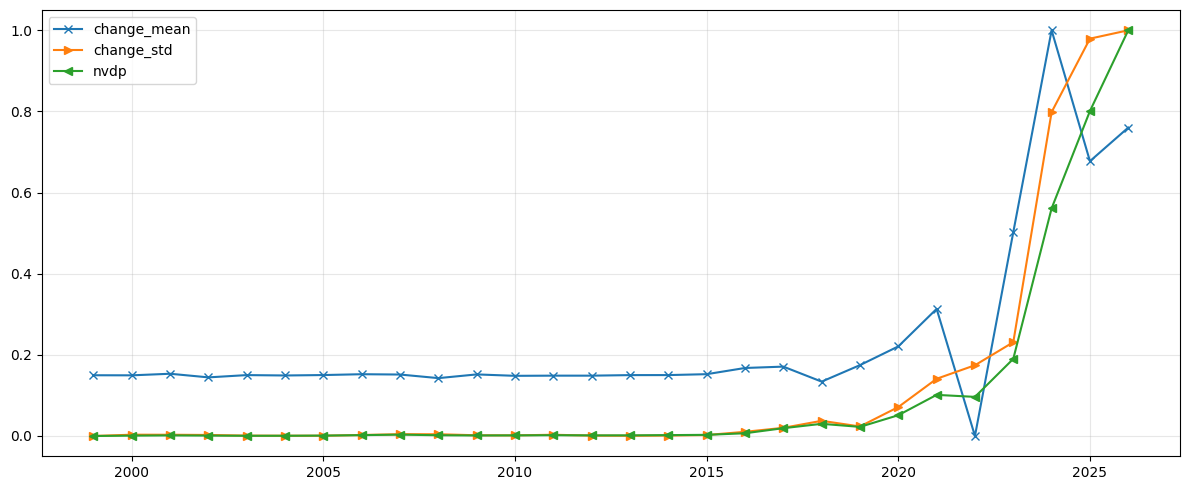

In [70]:
import matplotlib.pyplot as plt

nydm = nvda_years_describe[("change", "mean")]
nyds = nvda_years_describe[("change", "std")]
nvdp = nvda_df.groupby(nvda_df.index.year)["Close"].mean()

plt.figure(figsize=(12, 5))

plt.plot(nydm.index, (nydm - nydm.min()) / (nydm.max() - nydm.min()), label = "change_mean", marker="x")
plt.plot(nyds.index, (nyds - nyds.min()) / (nyds.max() - nyds.min()), label = "change_std", marker=">")
plt.plot(nvdp.index, (nvdp - nvdp.min()) / (nvdp.max() - nvdp.min()), label = "nvdp", marker="<")

plt.legend()

plt.tight_layout()
plt.grid(True, alpha=0.3)

plt.show()
# plt.plot(nvda_years_describe.index, nvda_years_describe["mean"])
# plt.show()

